In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

In [2]:
# Load the cleaned 311 dataset
data = pd.read_csv("311_2025_manhattan_cleaned.csv")
print("Shape:", data.shape)
data.head()

Shape: (18743, 19)


,unique_key,created_date,closed_date,year,month,season,day_of_week,hour,is_weekend,complaint_type,descriptor,agency,location_type,incident_zip,incident_address,community_board,resolution_description,response_hours,response_hours_flag
0,63800912,2025-01-17 17:45:55,2025-02-24 16:49:54,2025,1,Winter,4,17,0,General,Bell/Buzzer/Intercom,HPD,Residential Building,10028,509 EAST 81 STREET,08 MANHATTAN,HPD attempted to conduct an inspection in resp...,911.066389,0
1,63794210,2025-01-17 17:46:39,2025-01-23 00:00:00,2025,1,Winter,4,17,0,Investigations And Discipline (Iad),Investigative Inspection,DOB,NaN,10021,150 EAST 69 STREET,08 MANHATTAN,The Department of Buildings investigated this ...,126.222500,0
2,63795390,2025-01-17 17:47:00,2025-01-18 01:05:00,2025,1,Winter,4,17,0,Water System,Dirty Water (We),DEP,NaN,10036,520 WEST 43 STREET,04 MANHATTAN,The Department of Environmental Protection inv...,7.300000,0
3,63793374,2025-01-17 17:48:56,2025-01-21 10:08:46,2025,1,Winter,4,17,0,Heat/Hot Water,Entire Building,HPD,Residential Building,10031,541 WEST 142 STREET,09 MANHATTAN,This complaint is a duplicate of a building-wi...,88.330556,0
4,63798442,2025-01-17 17:48:56,2025-01-21 10:08:46,2025,1,Winter,4,17,0,Heat/Hot Water,Entire Building,HPD,Residential Building,10031,541 WEST 142 STREET,09 MANHATTAN,This complaint is a duplicate of a building-wi...,88.330556,0


## EDA: Overview of Manhattan 311 complaints in 2025

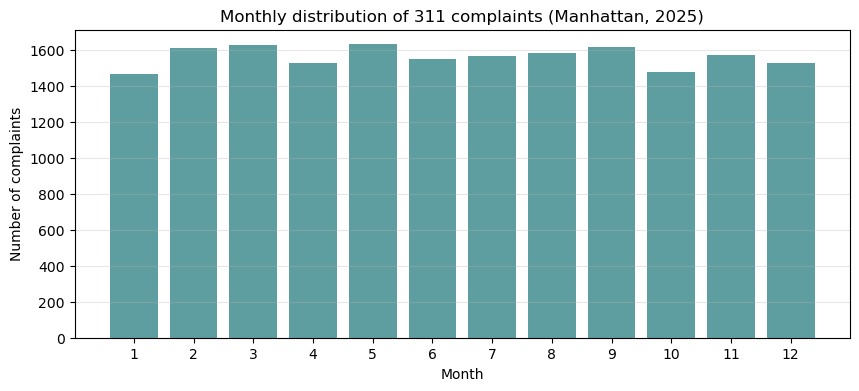

Average per month: 1562


In [3]:
# Monthly distribution: confirms balanced random monthly sampling
monthly_counts = data['month'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(monthly_counts.index, monthly_counts.values, color='cadetblue')
plt.xlabel('Month')
plt.ylabel('Number of complaints')
plt.title('Monthly distribution of 311 complaints (Manhattan, 2025)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Average per month: {monthly_counts.mean():.0f}")

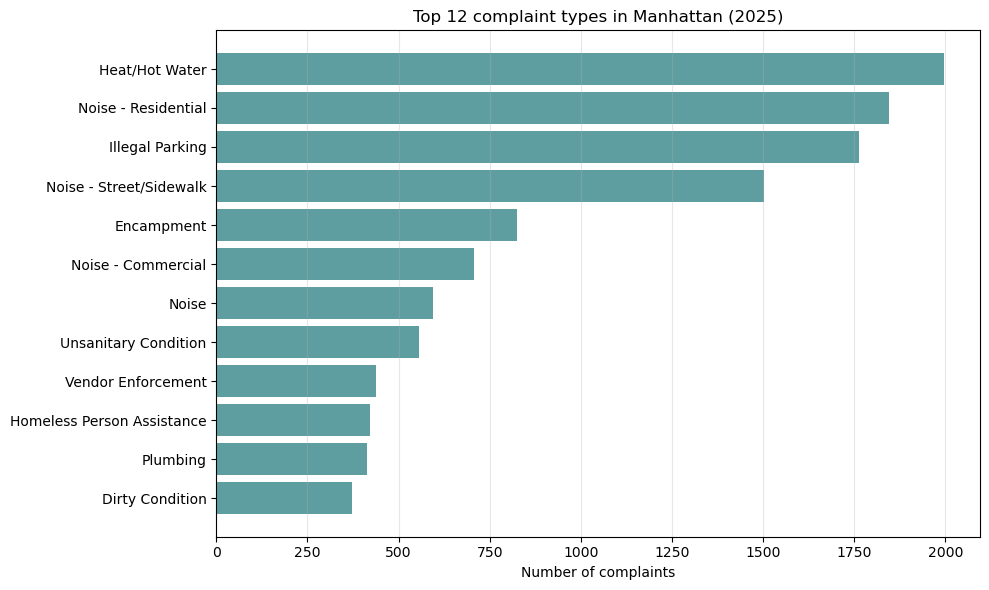

Top 4 complaint types account for 37.9% of all complaints


In [4]:
# Top 12 complaint types
complaint_counts = data['complaint_type'].value_counts()
top12 = complaint_counts.head(12).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top12.index, top12.values, color='cadetblue')
plt.xlabel('Number of complaints')
plt.title('Top 12 complaint types in Manhattan (2025)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

top4_share = complaint_counts.head(4).sum() / len(data) * 100
print(f"Top 4 complaint types account for {top4_share:.1f}% of all complaints")

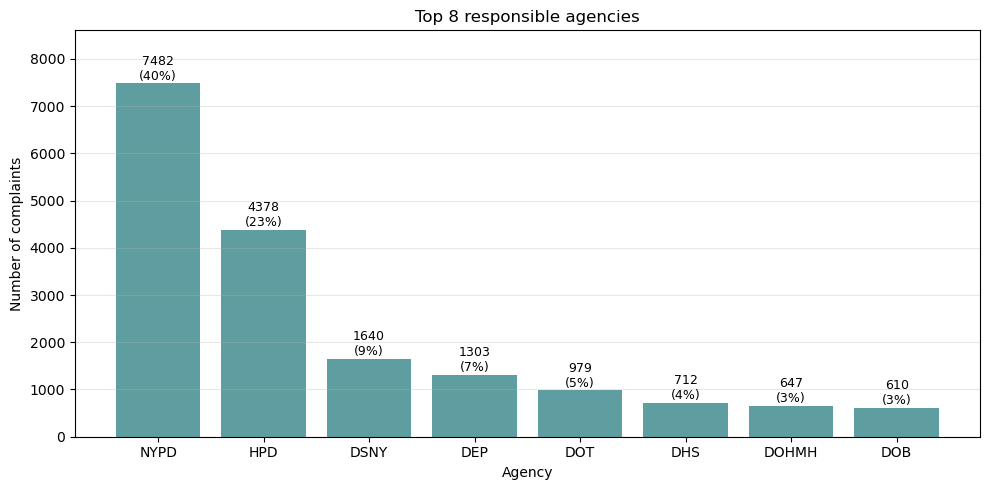

NYPD + HPD handle 63.3% of all complaints


In [5]:
# Top 8 responsible agencies
agency_counts = data['agency'].value_counts()
top8 = agency_counts.head(8)

plt.figure(figsize=(10, 5))
plt.bar(top8.index, top8.values, color='cadetblue')
plt.xlabel('Agency')
plt.ylabel('Number of complaints')
plt.title('Top 8 responsible agencies')
plt.grid(axis='y', alpha=0.3)

for i, (agency, count) in enumerate(top8.items()):
    pct = count / len(data) * 100
    plt.text(i, count + 80, f'{count}\n({pct:.0f}%)', ha='center', fontsize=9)

plt.ylim(0, top8.max() * 1.15)
plt.tight_layout()
plt.show()

top2_share = agency_counts.head(2).sum() / len(data) * 100
print(f"NYPD + HPD handle {top2_share:.1f}% of all complaints")

## RQ1: Identifying complaint themes through text analysis

In [6]:
# Drop missing descriptors and clean text using regex
desc_data = data.dropna(subset=['descriptor']).copy()

cleaned_desc = []
for text in desc_data['descriptor']:
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    cleaned_desc.append(text)

desc_data['descriptor_clean'] = cleaned_desc
print(f"Records with valid descriptor: {len(desc_data)}")

Records with valid descriptor: 17670


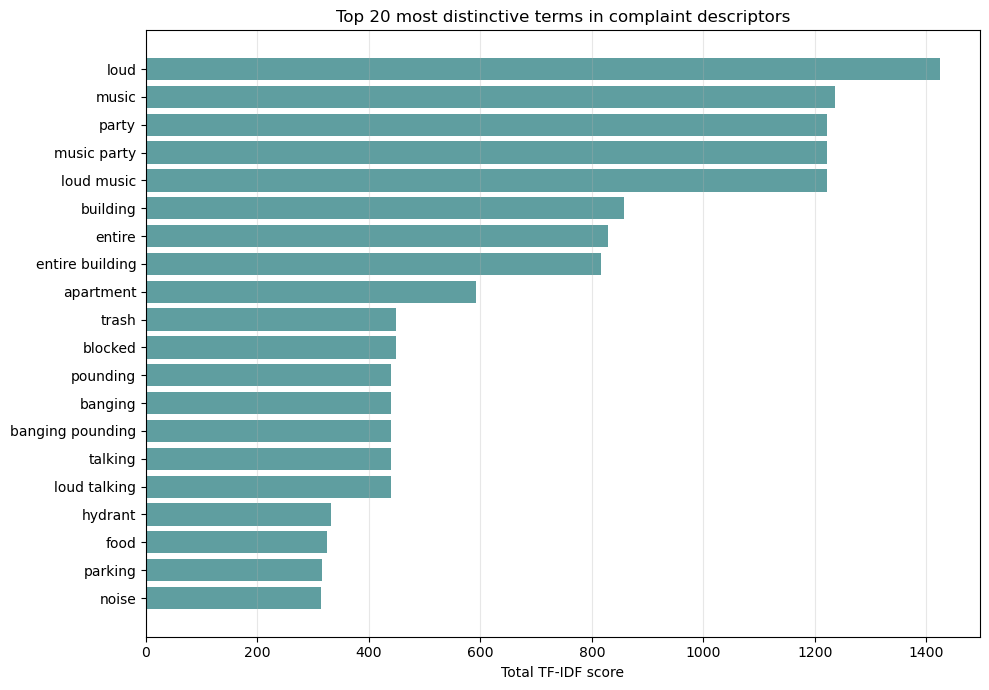

In [7]:
# TF-IDF on cleaned descriptors
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=100,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(desc_data['descriptor_clean'])
feature_names = tfidf_vectorizer.get_feature_names_out()

# Top 20 distinctive terms by total TF-IDF score
term_scores = tfidf_matrix.toarray().sum(axis=0)
term_score_df = pd.DataFrame({
    'term': feature_names,
    'tfidf_score': term_scores
}).sort_values('tfidf_score', ascending=False)

top20 = term_score_df.head(20).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top20['term'], top20['tfidf_score'], color='cadetblue')
plt.xlabel('Total TF-IDF score')
plt.title('Top 20 most distinctive terms in complaint descriptors')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

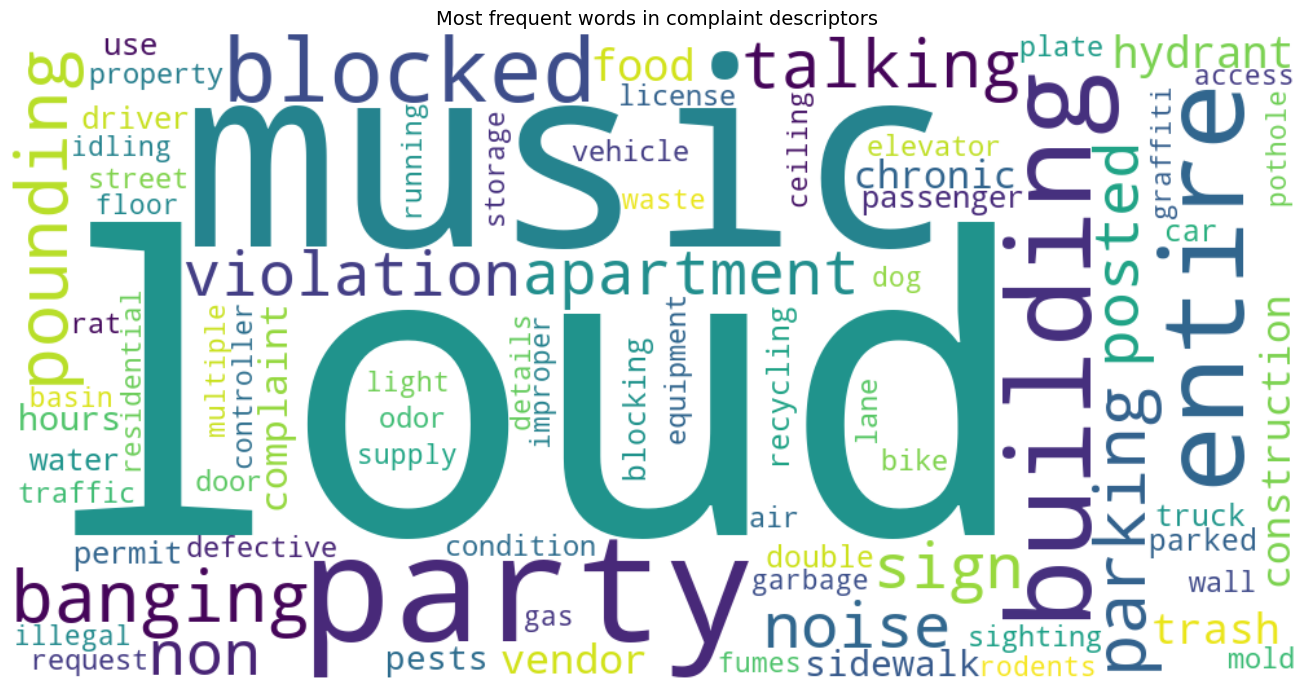

In [8]:
# Word cloud of frequent words (after stopword removal)
all_words = []
for text in desc_data['descriptor_clean']:
    all_words.extend(text.split())

english_stopwords = set(stopwords.words('english'))
all_words = [w for w in all_words if w not in english_stopwords and len(w) > 2]

word_freq = Counter(all_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=80,
    colormap='viridis'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in complaint descriptors', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# LDA topic modeling: K=4 was selected after comparing K=3, 4, and 5
# (see working notebook for the full comparison)
count_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=100,
    ngram_range=(1, 2)
)
count_matrix = count_vectorizer.fit_transform(desc_data['descriptor_clean'])
count_feature_names = count_vectorizer.get_feature_names_out()

lda = LatentDirichletAllocation(
    n_components=4,
    random_state=617,
    max_iter=50
)
lda.fit(count_matrix)

print("LDA topics (top 12 words each):\n")
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-12:][::-1]
    top_words = [count_feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

LDA topics (top 12 words each):

Topic 1: trash, chronic, non, non chronic, recycling, plate, condition, license, door, mold, license plate, floor
Topic 2: music, loud, party, music party, loud music, apartment, blocked, hydrant, sidewalk, blocked hydrant, use, water
Topic 3: parking, sign, violation, posted, parking sign, sign violation, posted parking, noise, construction, complaint, noise construction, hours
Topic 4: building, entire, entire building, banging, banging pounding, pounding, talking, loud talking, loud, food, vendor, food vendor


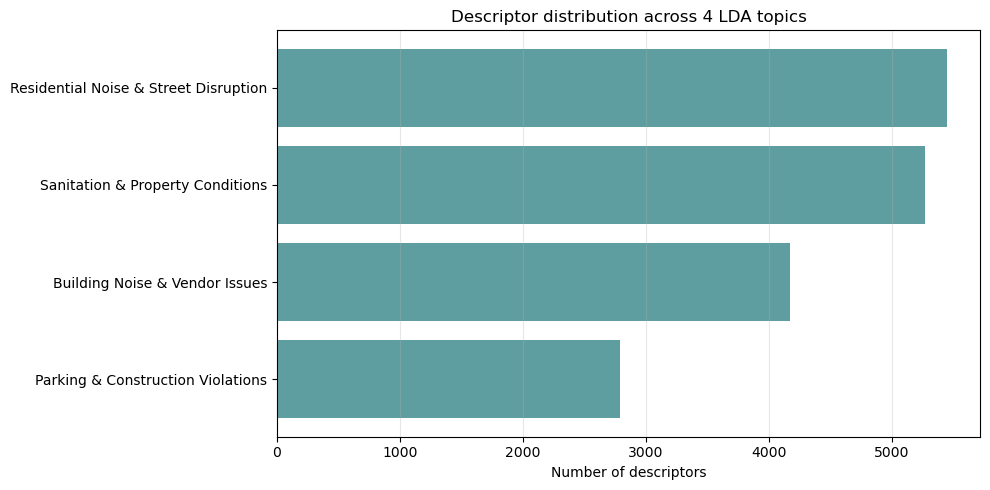

Topic distribution:
topic_name
Residential Noise & Street Disruption    5442
Sanitation & Property Conditions         5267
Building Noise & Vendor Issues           4171
Parking & Construction Violations        2790
Name: count, dtype: int64


In [10]:
# Assign each descriptor its dominant topic
topic_distributions = lda.transform(count_matrix)
dominant_topic = topic_distributions.argmax(axis=1)

topic_names = {
    0: 'Sanitation & Property Conditions',
    1: 'Residential Noise & Street Disruption',
    2: 'Parking & Construction Violations',
    3: 'Building Noise & Vendor Issues'
}

desc_data['topic_id'] = dominant_topic
desc_data['topic_name'] = desc_data['topic_id'].map(topic_names)

# Distribution
topic_counts = desc_data['topic_name'].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(topic_counts.index[::-1], topic_counts.values[::-1], color='cadetblue')
plt.xlabel('Number of descriptors')
plt.title('Descriptor distribution across 4 LDA topics')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Topic distribution:")
print(topic_counts)

In [11]:
# Notebook metadata
import sys
import platform
import importlib.metadata as md

libs = ["numpy", "pandas", "matplotlib", "scikit-learn", "scipy", "nltk", "wordcloud"]
versions = []
for lib in libs:
    try:
        versions.append(f"{lib} {md.version(lib)}")
    except md.PackageNotFoundError:
        pass

print(
    f"This notebook was generated using Python {sys.version.split()[0]} "
    f"on {platform.system()} {platform.release()} with the following libraries: "
    + ", ".join(versions)
)

This notebook was generated using Python 3.11.13 on Darwin 22.5.0 with the following libraries: numpy 2.4.4, pandas 3.0.2, matplotlib 3.10.8, scikit-learn 1.8.0, scipy 1.17.1, nltk 3.9.4, wordcloud 1.9.6
